In [1]:
# Stock Price Prediction Using Multi-Feature LSTM
# Week 5
# This notebook builds a stock price prediction model using LSTM.  
# The model uses multiple input features instead of only the closing price.

# Features used:
# - Close
# - Volume
# - High
# - Low

# Main goals:
# - prepare stock data for deep learning
# - handle missing values before training
# - scale the data into a suitable range
# - train an LSTM model
# - compare predicted prices with actual prices

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import yfinance as yf

from tensorflow.keras import mixed_precision
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM

In [3]:
## Mixed precision setting

In [4]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

In [5]:
## Stock selection and training period

# Here I define the stock ticker and the period used for training data.

In [6]:
COMPANY = 'CBA.AX'

TRAIN_START = '2020-01-01'
TRAIN_END = '2023-08-01'

TEST_START = '2023-08-02'
TEST_END = '2024-07-02'

In [7]:
## Download training data

In [8]:
data = yf.download(COMPANY, TRAIN_START, TRAIN_END)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CBA.AX,CBA.AX,CBA.AX,CBA.AX,CBA.AX
Date,,,,,
2020-01-02,63.102207,63.370798,62.715127,63.031113,1416232
2020-01-03,63.441898,64.137069,63.394503,63.963277,1622784
2020-01-06,63.015320,63.102216,62.588745,62.983727,2129260
2020-01-07,64.144974,64.144974,63.339214,63.844790,2417468
2020-01-08,63.907993,64.184479,63.220723,64.160781,1719114


In [9]:
## Data preparation function

In [10]:
def load_and_prepare_multi_feature_data(
    data,
    feature_columns=['Close', 'Volume', 'High', 'Low'],
    target_column='Close',
    prediction_days=60
):
    # Keep only the selected columns
    dataset = data[feature_columns].copy()

    # Fill missing values before training
    dataset = dataset.ffill().bfill()

    # Safety check
    if dataset.isnull().sum().sum() > 0:
        raise ValueError("Dataset still contains NaN values after preprocessing.")

    # Scale all features to the range (0, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(dataset)

    # Create input sequences and target values
    x_train = []
    y_train = []

    target_index = feature_columns.index(target_column)

    for i in range(prediction_days, len(scaled_data)):
        x_train.append(scaled_data[i - prediction_days:i])
        y_train.append(scaled_data[i, target_index])

    x_train = np.array(x_train)
    y_train = np.array(y_train)

    return x_train, y_train, scaler, dataset

In [11]:
## Prepare training data

# The model uses four input features:
# - Close
# - Volume
# - High
# - Low

# The target value remains the closing price.

In [12]:
FEATURE_COLUMNS = ['Close', 'Volume', 'High', 'Low']
TARGET_COLUMN = 'Close'
PREDICTION_DAYS = 60

x_train, y_train, scaler, cleaned_data = load_and_prepare_multi_feature_data(
    data=data,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    prediction_days=PREDICTION_DAYS
)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (845, 60, 4)
y_train shape: (845,)


In [13]:
### What these shapes mean

# - `x_train` contains the training sequences  
# - each sequence uses 60 previous trading days  
# - each day has 4 features  
# - `y_train` contains the value to predict, which is the closing price

In [14]:
## Build the LSTM model

# This model uses stacked LSTM layers to learn price patterns over time.

# - LSTM layers learn from sequential data
# - Dropout layers help reduce overfitting
# - the final Dense layer outputs one predicted value

In [15]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

D:\anaconda3\envs\COS30018\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,451 (200.98 KB)

 Trainable params: 51,451 (200.98 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
## Train the model

# The model is trained for 30 epochs using batch size 32.

In [17]:
history = model.fit(x_train, y_train, epochs=30, batch_size=32)

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 0.0976
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0116
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - loss: 0.0086
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - loss: 0.0081
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - loss: 0.0071
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - loss: 0.0065
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - loss: 0.0074
Epoch 8/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0071
Epoch 9/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - loss: 0.0068
Epoch 10/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0063
Epoch 11/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - loss: 0.0069
Epoch 12/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - loss: 0.0058
Epoch 13/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - loss: 0.0062
Epoch 14/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - loss: 0.0057
Epoch 15/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 139ms/step - lo

In [18]:
## Download test data

In [19]:
test_data = yf.download(COMPANY, TEST_START, TEST_END)
test_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CBA.AX,CBA.AX,CBA.AX,CBA.AX,CBA.AX
Date,,,,,
2023-08-02,93.369164,95.074824,93.035249,94.966533,2074443
2023-08-03,92.466690,93.260858,92.105702,92.917923,2890772
2023-08-04,91.934250,93.089406,91.780825,92.683292,2687798
2023-08-07,91.916191,92.250106,91.591303,92.132781,2771020
2023-08-08,92.241074,92.574989,91.988384,92.412544,3241229


In [20]:
## Prepare test inputs
# This section:
# - keeps the same selected features
# - combines training and test data
# - takes the last 60 days before each prediction
# - applies the same scaler used during training

In [21]:
actual_prices = test_data[TARGET_COLUMN].values

total_dataset = pd.concat((data[FEATURE_COLUMNS], test_data[FEATURE_COLUMNS]), axis=0)

model_inputs = total_dataset[len(total_dataset) - len(test_data) - PREDICTION_DAYS:].copy()
model_inputs = model_inputs.ffill().bfill()
model_inputs = scaler.transform(model_inputs)

In [22]:
## Create test sequences and make predictions

# The loop below creates input sequences for the test set.

# Each test sample contains:
# - 60 previous days
# - 4 features for each day

# The model outputs predictions in scaled form, so the results are converted back to the original price scale. 

In [23]:
x_test = []

for x in range(PREDICTION_DAYS, len(model_inputs)):
    x_test.append(model_inputs[x - PREDICTION_DAYS:x])

x_test = np.array(x_test)

predicted_scaled = model.predict(x_test)

target_index = FEATURE_COLUMNS.index(TARGET_COLUMN)

dummy = np.zeros((len(predicted_scaled), len(FEATURE_COLUMNS)))
dummy[:, target_index] = predicted_scaled[:, 0]

predicted_prices = scaler.inverse_transform(dummy)[:, target_index]

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step


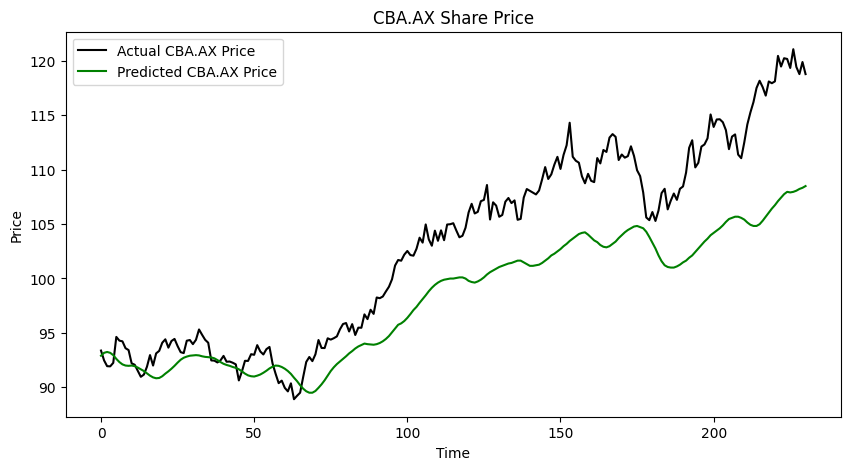

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted next closing price: 108.54032245278358


In [24]:
## Compare actual and predicted prices
plt.figure(figsize=(10, 5))
plt.plot(actual_prices, color="black", label=f"Actual {COMPANY} Price")
plt.plot(predicted_prices, color="green", label=f"Predicted {COMPANY} Price")
plt.title(f"{COMPANY} Share Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

## Predict the next trading day

# This section uses the latest 60 days of input data to estimate the next closing price.
real_data = [model_inputs[len(model_inputs) - PREDICTION_DAYS:]]
real_data = np.array(real_data)

prediction_scaled = model.predict(real_data)

dummy = np.zeros((1, len(FEATURE_COLUMNS)))
dummy[0, target_index] = prediction_scaled[0, 0]

prediction = scaler.inverse_transform(dummy)[:, target_index]
print(f"Predicted next closing price: {prediction[0]}")